
# 02 — Sensitivity Studies

This notebook demonstrates reproducible sensitivity studies for:

- Temperature: 100, 150, and 200°C
- Fracture dimensions/reactive area
- Injection-rate scaling
- Thirty-year multi-cycle refracturing
- Optional fixed CO₂ impurity split


In [1]:
from pathlib import Path
from dataclasses import dataclass, replace
from typing import Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve

REPO_ROOT = Path.cwd()
OUTPUT_DIR = REPO_ROOT / "results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ===== constants.py =====
IN2_TO_M2 = 6.4516e-4
DAY_TO_S = 86400.0

# ===== config.py =====

@dataclass(frozen=True)
class GeometryConfig:
    Lx_m: float = 0.0381
    Ly_m: float = 0.0025
    Lz_m: float = 0.0762
    nx: int = 80
    ny: int = 5
    nz: int = 80
    fracture_aperture_m: float = 0.0025
    number_of_fractures: int = 1

    def __post_init__(self):
        if min(self.Lx_m, self.Ly_m, self.Lz_m, self.fracture_aperture_m) <= 0:
            raise ValueError('Geometry lengths and aperture must be positive.')
        if min(self.nx, self.ny, self.nz, self.number_of_fractures) < 1:
            raise ValueError('Grid counts and number of fractures must be positive integers.')

    @property
    def dx_m(self): return self.Lx_m / self.nx
    @property
    def dy_m(self): return self.Ly_m / self.ny
    @property
    def dz_m(self): return self.Lz_m / self.nz
    @property
    def reactive_area_m2(self): return 2.0*self.Lx_m*self.Lz_m*self.number_of_fractures
    @property
    def reactive_area_in2(self): return self.reactive_area_m2/IN2_TO_M2
    @property
    def flow_area_m2(self): return self.fracture_aperture_m*self.Lz_m*self.number_of_fractures
    @property
    def fracture_volume_m3(self): return self.Lx_m*self.fracture_aperture_m*self.Lz_m*self.number_of_fractures

@dataclass(frozen=True)
class RateConfig:
    qmax_ref_m3_day: float = 2.737e-8
    area_ref_in2: float = 9.0
    beta_area: float = 1.510
    tr_ref_day: float = 3.527
    kr_ref_day_inv: float = 0.736
    alpha_tr: float = 0.25
    alpha_kr: float = -0.15
    tp_slope_day_per_in2: float = 1.1735e-5
    tp_intercept_day: float = 5.99989
    tp_cap_day: float = 1825.0
    tau_ref_day: float = 11.523
    alpha_tau: float = 0.20
    tau_cap_day: float = 1000.0
    m_base: float = 1.5
    alpha_m: float = 0.05
    m_cap: float = 2.0
    temperature_timing_exponent: float = 0.5

@dataclass(frozen=True)
class HydraulicConfig:
    lab_injection_rate_m3_day: float = 1.5e-4
    reference_area_in2: float = 9.0
    injection_area_exponent: float = 1.0
    explicit_injection_rate_m3_day: Optional[float] = None
    producer_pressure_pa: float = 3.7e6
    viscosity_pa_s: float = 3.0e-4
    fracture_permeability_m2: float = 6.14e-11
    fracture_porosity: float = 0.45

@dataclass(frozen=True)
class ThermalConfig:
    initial_temperature_C: float = 100.0
    injection_temperature_C: float = 100.0
    far_field_temperature_C: float = 100.0
    enable_temperature_evolution: bool = False
    rho_f: float = 950.0
    cp_f: float = 4200.0
    heat_transfer_coefficient_w_m2_k: float = 0.0

@dataclass(frozen=True)
class ChemicalConfig:
    D_h2_m2_s: float = 4.5e-9
    h2_molar_volume_std_m3_mol: float = 2.2414e-2
    injected_h2_mol_m3: float = 0.0
    source_distribution: str = 'uniform'
    source_decay_length_fraction: float = 0.25
    enable_additional_inventory_limit: bool = False
    h2_capacity_mol_per_m2: float = 1.0e9

@dataclass(frozen=True)
class MechanicalConfig:
    enable: bool = False
    reference_pressure_pa: float = 3.7e6
    reference_temperature_C: float = 100.0
    normal_stiffness_pa_m: float = 1.0e13
    thermal_aperture_coefficient_m_per_K: float = 0.0
    chemical_aperture_fraction_at_full_progress: float = 0.0
    min_aperture_fraction: float = 0.10
    max_aperture_fraction: float = 3.00

@dataclass(frozen=True)
class SimulationConfig:
    total_days: float = 30.0
    dt_day: float = 0.05
    save_every: int = 20

# ===== chemistry.py =====

def temperature_factor(T_C: float) -> float:
    T_C=float(T_C)
    if T_C <= 100.0: return 1.0
    if T_C <= 150.0: return 1.0 + 0.06*(T_C-100.0)
    if T_C <= 200.0: return 4.0 + 0.08*(T_C-150.0)
    return 8.0 + 0.08*(T_C-200.0)

def kinetic_parameters(area_in2: float, T_C: float, cfg: RateConfig | None=None) -> dict[str,float]:
    cfg=cfg or RateConfig()
    ar=max(area_in2/cfg.area_ref_in2,1e-30)
    FT=temperature_factor(T_C)
    ST=FT**cfg.temperature_timing_exponent
    return {'F_T':FT,'qmax_m3_day':cfg.qmax_ref_m3_day*ar**cfg.beta_area*FT,
            'tr_day':cfg.tr_ref_day*ar**cfg.alpha_tr/ST,
            'kr_day_inv':cfg.kr_ref_day_inv*ar**cfg.alpha_kr*ST,
            'tp_day':min(cfg.tp_slope_day_per_in2*area_in2+cfg.tp_intercept_day,cfg.tp_cap_day)/ST,
            'tau_day':min(cfg.tau_ref_day*ar**cfg.alpha_tau,cfg.tau_cap_day)/ST,
            'm_eff':min(cfg.m_base*ar**cfg.alpha_m,cfg.m_cap)}

def normalized_logistic(t_day, tr_day: float, kr_day_inv: float):
    t=np.asarray(t_day,dtype=float)
    raw=1/(1+np.exp(np.clip(-kr_day_inv*(t-tr_day),-700,700)))
    raw0=1/(1+np.exp(np.clip(kr_day_inv*tr_day,-700,700)))
    return np.maximum((raw-raw0)/max(1-raw0,1e-30),0.0)

def passivation(t_day,tp_day:float,tau_day:float,m_shape:float):
    t=np.asarray(t_day,dtype=float)
    return np.exp(-(np.maximum(t-tp_day,0.0)/max(tau_day,1e-30))**m_shape)

def analytical_generation_rate_m3_day(t_day, area_in2:float, T_C:float, cfg:RateConfig|None=None):
    cfg=cfg or RateConfig(); p=kinetic_parameters(area_in2,T_C,cfg)
    return p['qmax_m3_day']*normalized_logistic(t_day,p['tr_day'],p['kr_day_inv'])*passivation(t_day,p['tp_day'],p['tau_day'],p['m_eff'])

def source_weights(geom:GeometryConfig, chem:ChemicalConfig):
    xn=(np.arange(geom.nx)+0.5)/geom.nx
    if chem.source_distribution=='uniform': w=np.ones(geom.nx)
    elif chem.source_distribution=='inlet_weighted': w=np.exp(-xn/max(chem.source_decay_length_fraction,1e-6))
    elif chem.source_distribution=='outlet_weighted': w=np.exp(-(1-xn)/max(chem.source_decay_length_fraction,1e-6))
    else: raise ValueError('source_distribution must be uniform, inlet_weighted, or outlet_weighted.')
    return w/w.sum()

def distributed_source_mol_s(q_m3_day:float, geom:GeometryConfig, chem:ChemicalConfig):
    total=q_m3_day/chem.h2_molar_volume_std_m3_mol/DAY_TO_S
    source=total*source_weights(geom,chem)
    if not np.isclose(source.sum(),total,rtol=1e-12,atol=1e-30): raise RuntimeError('Source distribution is not conservative.')
    return source

def inventory_fraction(cum_gen_mol:float,geom:GeometryConfig,chem:ChemicalConfig)->float:
    if not chem.enable_additional_inventory_limit: return 1.0
    cap=geom.reactive_area_m2*chem.h2_capacity_mol_per_m2
    return float(np.clip(1-cum_gen_mol/max(cap,1e-30),0,1))

# ===== hydraulics.py =====

def resolved_injection_rate_m3_day(geom:GeometryConfig,hyd:HydraulicConfig)->float:
    if hyd.explicit_injection_rate_m3_day is not None:
        if hyd.explicit_injection_rate_m3_day<=0: raise ValueError('Explicit injection rate must be positive.')
        return hyd.explicit_injection_rate_m3_day
    ar=max(geom.reactive_area_in2/hyd.reference_area_in2,1e-30)
    return hyd.lab_injection_rate_m3_day*ar**hyd.injection_area_exponent

def build_grid_3d(geom:GeometryConfig):
    x=(np.arange(geom.nx)+0.5)*geom.dx_m; y=(np.arange(geom.ny)+0.5)*geom.dy_m; z=(np.arange(geom.nz)+0.5)*geom.dz_m
    X,Y,Z=np.meshgrid(x,y,z,indexing='ij')
    frac=np.abs(Y-0.5*geom.Ly_m)<=0.5*geom.fracture_aperture_m
    return {'x':x,'y':y,'z':z,'X':X,'Y':Y,'Z':Z,'fracture_mask':frac}

def hydraulic_state(geom:GeometryConfig,hyd:HydraulicConfig,aperture_m:float):
    Qd=resolved_injection_rate_m3_day(geom,hyd); Q=Qd/DAY_TO_S
    Aflow=aperture_m*geom.Lz_m*geom.number_of_fractures
    v=Q/Aflow
    k=hyd.fracture_permeability_m2*(aperture_m/geom.fracture_aperture_m)**2
    gradp=-hyd.viscosity_pa_s*v/k
    x=(np.arange(geom.nx)+0.5)*geom.dx_m
    p=hyd.producer_pressure_pa+gradp*(x-geom.Lx_m)
    return {'Q_m3_day':Qd,'Q_m3_s':Q,'flow_area_m2':Aflow,'velocity_m_s':v,
            'permeability_m2':k,'pressure_gradient_pa_m':gradp,'pressure_pa':p}

# ===== thermal.py =====

def solve_temperature_step(Told,H,geom:GeometryConfig,hyd:HydraulicConfig,th:ThermalConfig,dt_s:float,aperture:float):
    if not th.enable_temperature_evolution: return np.full(geom.nx,th.initial_temperature_C)
    A=lil_matrix((geom.nx,geom.nx)); b=np.zeros(geom.nx)
    poreV=hyd.fracture_porosity*geom.dx_m*aperture*geom.Lz_m*geom.number_of_fractures
    accum=th.rho_f*th.cp_f*poreV/dt_s; Hadv=th.rho_f*th.cp_f*H['Q_m3_s']
    Aex=2*geom.dx_m*geom.Lz_m*geom.number_of_fractures; Hrock=th.heat_transfer_coefficient_w_m2_k*Aex
    for i in range(geom.nx):
        A[i,i]=accum+Hadv+Hrock; b[i]=accum*Told[i]+Hrock*th.far_field_temperature_C
        if i==0: b[i]+=Hadv*th.injection_temperature_C
        else: A[i,i-1]-=Hadv
    return spsolve(csr_matrix(A),b)

# ===== transport.py =====

def solve_h2_step(cold,source_mol_s_cell,H,geom:GeometryConfig,hyd:HydraulicConfig,chem:ChemicalConfig,dt_s:float,aperture:float):
    n=geom.nx; A=lil_matrix((n,n)); b=np.zeros(n)
    bulkV=geom.dx_m*aperture*geom.Lz_m*geom.number_of_fractures
    poreV=hyd.fracture_porosity*bulkV; accum=poreV/dt_s
    G=hyd.fracture_porosity*chem.D_h2_m2_s*H['flow_area_m2']/geom.dx_m; Q=H['Q_m3_s']
    for i in range(n):
        diag=accum; b[i]=accum*cold[i]+source_mol_s_cell[i]
        if i>0: diag+=G; A[i,i-1]-=G
        if i<n-1: diag+=G; A[i,i+1]-=G
        diag+=Q
        if i==0: b[i]+=Q*chem.injected_h2_mol_m3
        else: A[i,i-1]-=Q
        A[i,i]+=diag
    c=np.maximum(spsolve(csr_matrix(A),b),0)
    return c,float(Q*c[-1])

# ===== mechanics.py =====

def update_aperture(geom:GeometryConfig,mech:MechanicalConfig,mean_p:float,mean_T:float,progress:float)->float:
    b0=geom.fracture_aperture_m
    if not mech.enable: return b0
    b=(b0+(mean_p-mech.reference_pressure_pa)/max(mech.normal_stiffness_pa_m,1e-30)
       +mech.thermal_aperture_coefficient_m_per_K*(mean_T-mech.reference_temperature_C)
       +b0*mech.chemical_aperture_fraction_at_full_progress*progress)
    return float(np.clip(b,mech.min_aperture_fraction*b0,mech.max_aperture_fraction*b0))

# ===== solver.py =====

def run_thcm_case(case_name:str,geom:GeometryConfig,rate:RateConfig,hyd:HydraulicConfig,thermal:ThermalConfig,chem:ChemicalConfig,mech:MechanicalConfig,sim:SimulationConfig):
    grid=build_grid_3d(geom); dt_s=sim.dt_day*DAY_TO_S; nsteps=int(round(sim.total_days/sim.dt_day))
    c=np.zeros(geom.nx); T=np.full(geom.nx,thermal.initial_temperature_C); aperture=geom.fracture_aperture_m
    cum_gen=cum_prod=0.0; history=[]; snapshots={}
    for step in range(1,nsteps+1):
        t=step*sim.dt_day; H=hydraulic_state(geom,hyd,aperture)
        T=solve_temperature_step(T,H,geom,hyd,thermal,dt_s,aperture); Tmean=float(T.mean())
        q_anal=float(analytical_generation_rate_m3_day(t,geom.reactive_area_in2,Tmean,rate))
        inv=inventory_fraction(cum_gen,geom,chem); q_applied=q_anal*inv
        src=distributed_source_mol_s(q_applied,geom,chem); gen_step=src.sum()*dt_s
        c,prod_mol_s=solve_h2_step(c,src,H,geom,hyd,chem,dt_s,aperture); prod_step=prod_mol_s*dt_s
        cum_gen+=gen_step; cum_prod+=prod_step
        poreV=hyd.fracture_porosity*geom.Lx_m*aperture*geom.Lz_m*geom.number_of_fractures
        stored=float(c.mean()*poreV); residual=cum_gen-cum_prod-stored; relerr=abs(residual)/max(cum_gen,1e-30)
        qprod=prod_mol_s*chem.h2_molar_volume_std_m3_mol*DAY_TO_S
        pkin=kinetic_parameters(geom.reactive_area_in2,Tmean,rate)
        progress=float(np.clip(cum_gen*chem.h2_molar_volume_std_m3_mol/max(pkin['qmax_m3_day']*max(sim.total_days,1),1e-30),0,1))
        aperture=update_aperture(geom,mech,float(H['pressure_pa'].mean()),Tmean,progress)
        history.append({'case_name':case_name,'time_day':t,'reactive_area_m2':geom.reactive_area_m2,
          'reactive_area_in2':geom.reactive_area_in2,'Lx_m':geom.Lx_m,'Ly_m':geom.Ly_m,'Lz_m':geom.Lz_m,
          'nx':geom.nx,'ny':geom.ny,'nz':geom.nz,'number_of_fractures':geom.number_of_fractures,
          'temperature_C':Tmean,'injection_rate_m3_day':H['Q_m3_day'],'aperture_m':aperture,
          'permeability_m2':H['permeability_m2'],'maximum_pressure_pa':float(H['pressure_pa'].max()),
          'analytical_generated_H2_m3_day':q_anal,'applied_generated_H2_m3_day':q_applied,
          'produced_H2_m3_day':qprod,'cumulative_generated_H2_mol':cum_gen,'cumulative_produced_H2_mol':cum_prod,
          'stored_H2_mol':stored,'relative_H2_balance_error':relerr,'inventory_remaining_fraction':inv})
        if step%sim.save_every==0 or step==nsteps:
            snapshots[t]={'pressure_pa':H['pressure_pa'].copy(),'temperature_C':T.copy(),
                          'H2_concentration_mol_m3':c.copy(),'aperture_m':aperture}
    return {'name':case_name,'geometry':geom,'grid':grid,'history':pd.DataFrame(history),'snapshots':snapshots}

# ===== benchmarks.py =====

def run_temperature_benchmarks(output_dir):
    out=Path(output_dir); out.mkdir(parents=True,exist_ok=True)
    geom=GeometryConfig(); rate=RateConfig(); hyd=HydraulicConfig(); chem=ChemicalConfig(); mech=MechanicalConfig(enable=False)
    sim=SimulationConfig(total_days=30.0,dt_day=0.1,save_every=50)
    summaries=[]
    for temp in (100.0,150.0,200.0):
        thermal=ThermalConfig(initial_temperature_C=temp,injection_temperature_C=temp,far_field_temperature_C=temp,enable_temperature_evolution=False)
        result=run_thcm_case(f'benchmark_{int(temp)}C',geom,rate,hyd,thermal,chem,mech,sim)
        hist=result['history']; hist.to_csv(out/f'benchmark_{int(temp)}C_history.csv',index=False)
        summaries.append({'temperature_C':temp,'peak_analytical_rate_m3_day':hist['analytical_generated_H2_m3_day'].max(),
          'peak_produced_rate_m3_day':hist['produced_H2_m3_day'].max(),'final_cumulative_generated_H2_mol':hist['cumulative_generated_H2_mol'].iloc[-1],
          'final_cumulative_produced_H2_mol':hist['cumulative_produced_H2_mol'].iloc[-1],
          'maximum_relative_mass_balance_error':hist['relative_H2_balance_error'].max()})
    summary=pd.DataFrame(summaries); summary.to_csv(out/'benchmark_summary.csv',index=False); return summary

# ===== visualization.py =====

def plot_rate_history(history,output_path=None,title='Hydrogen generation and production'):
    fig,ax=plt.subplots(figsize=(9,5))
    ax.plot(history['time_day'],history['analytical_generated_H2_m3_day'],label='Analytical generation')
    ax.plot(history['time_day'],history['produced_H2_m3_day'],label='Produced H₂')
    ax.set(xlabel='Time (day)',ylabel='H₂ rate (m³/day)',title=title); ax.grid(alpha=.3); ax.legend(); fig.tight_layout()
    if output_path: Path(output_path).parent.mkdir(parents=True,exist_ok=True); fig.savefig(output_path,dpi=300,bbox_inches='tight')
    return fig

def plot_validation(data,metrics,output_path=None):
    fig,ax=plt.subplots(figsize=(9,5))
    ax.scatter(data['time_day'],data['experimental_rate_m3_day'],label='Laboratory data',zorder=3)
    ax.plot(data['time_day'],data['simulated_rate_m3_day'],label='Analytical model')
    ax.set(xlabel='Time (day)',ylabel='H₂ generation rate (m³/day)',title=f"Laboratory validation (R²={metrics['r2']:.3f})")
    ax.grid(alpha=.3); ax.legend(); fig.tight_layout()
    if output_path: Path(output_path).parent.mkdir(parents=True,exist_ok=True); fig.savefig(output_path,dpi=600,bbox_inches='tight')
    return fig

## 1. Standard 100/150/200°C benchmark cases

In [2]:

benchmark_dir = OUTPUT_DIR / "benchmarks"
benchmark_summary = run_temperature_benchmarks(benchmark_dir)
benchmark_summary


,temperature_C,peak_analytical_rate_m3_day,peak_produced_rate_m3_day,final_cumulative_generated_H2_mol,final_cumulative_produced_H2_mol,maximum_relative_mass_balance_error
0,100.0,2.469431e-08,2.469409e-08,0.000015,0.000015,2.418966e-15
1,150.0,9.877724e-08,9.876916e-08,0.000031,0.000031,2.173054e-15
2,200.0,1.975625e-07,1.975092e-07,0.000043,0.000043,2.811244e-15


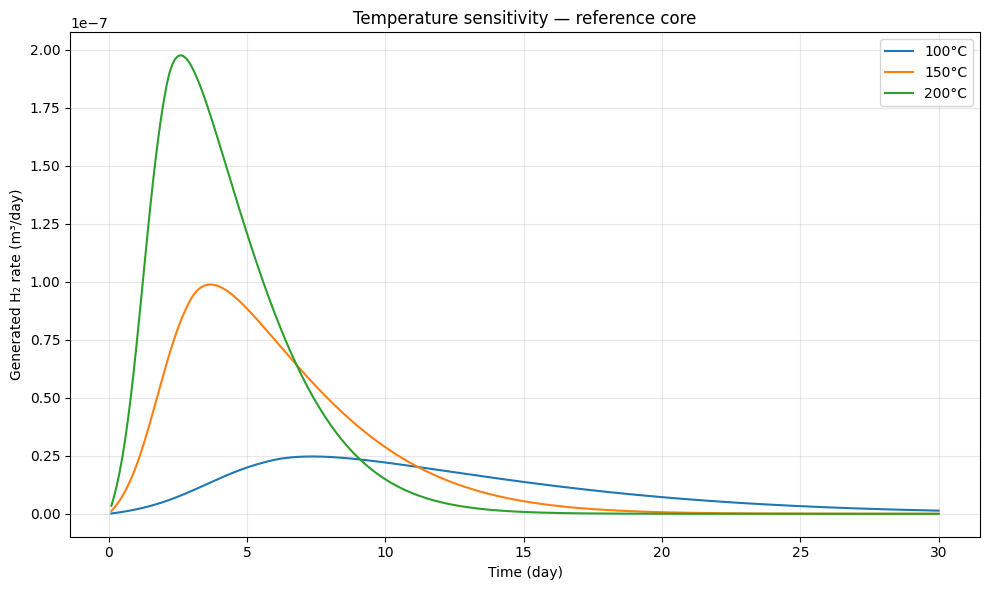

In [3]:

fig, ax = plt.subplots(figsize=(10, 6))
for temp in (100, 150, 200):
    h = pd.read_csv(benchmark_dir / f"benchmark_{temp}C_history.csv")
    ax.plot(h["time_day"], h["analytical_generated_H2_m3_day"], label=f"{temp}°C")
ax.set(xlabel="Time (day)", ylabel="Generated H₂ rate (m³/day)", title="Temperature sensitivity — reference core")
ax.grid(alpha=0.3); ax.legend(); fig.tight_layout()
fig.savefig(OUTPUT_DIR / "02_temperature_benchmark.png", dpi=300, bbox_inches="tight")
plt.show()


## 2. Geometry/reactive-area sensitivity

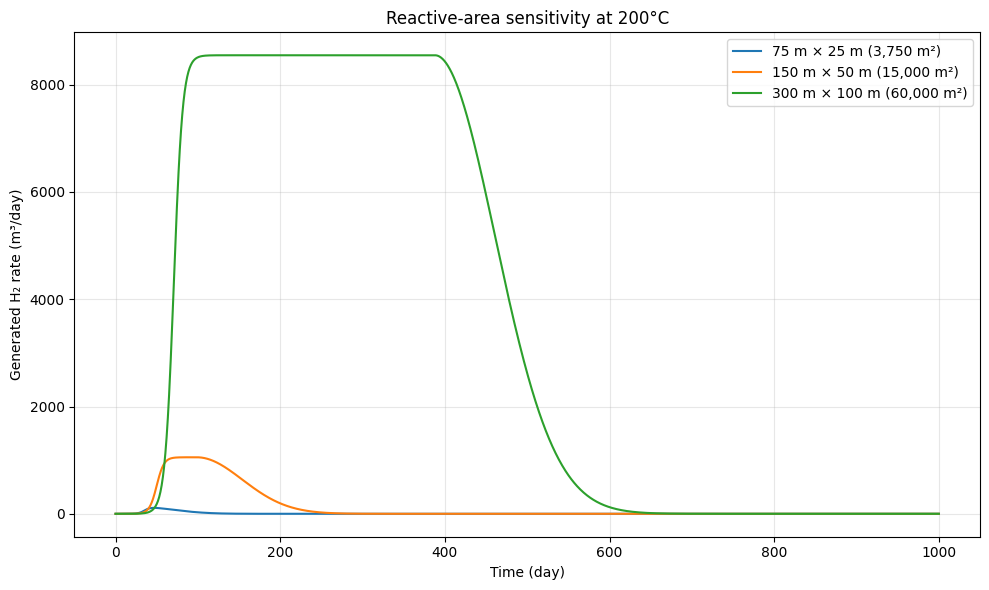

,case,area_m2,area_in2,peak_m3_day,peak_day
0,75 m × 25 m,3750.0,5.812512e+06,110.646903,46.5
1,150 m × 50 m,15000.0,2.325005e+07,1053.783762,98.5
2,300 m × 100 m,60000.0,9.300019e+07,8548.091436,270.0


In [4]:

rate = RateConfig()
time = np.linspace(0, 1000, 2001)
geometry_cases = {
    "75 m × 25 m": GeometryConfig(Lx_m=75, Ly_m=20, Lz_m=25, nx=80, ny=9, nz=30, fracture_aperture_m=0.005),
    "150 m × 50 m": GeometryConfig(Lx_m=150, Ly_m=20, Lz_m=50, nx=120, ny=9, nz=50, fracture_aperture_m=0.005),
    "300 m × 100 m": GeometryConfig(Lx_m=300, Ly_m=20, Lz_m=100, nx=160, ny=9, nz=70, fracture_aperture_m=0.005),
}
rows=[]
fig, ax = plt.subplots(figsize=(10, 6))
for label, g in geometry_cases.items():
    q = analytical_generation_rate_m3_day(time, g.reactive_area_in2, 200.0, rate)
    ax.plot(time, q, label=f"{label} ({g.reactive_area_m2:,.0f} m²)")
    rows.append({"case": label, "area_m2": g.reactive_area_m2, "area_in2": g.reactive_area_in2, "peak_m3_day": q.max(), "peak_day": time[np.argmax(q)]})
ax.set(xlabel="Time (day)", ylabel="Generated H₂ rate (m³/day)", title="Reactive-area sensitivity at 200°C")
ax.grid(alpha=0.3); ax.legend(); fig.tight_layout()
fig.savefig(OUTPUT_DIR / "02_area_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()
area_summary = pd.DataFrame(rows)
area_summary


## 3. Thirty-year multi-cycle refracturing

In [5]:

FRACTURE_LENGTH_M = 150.0
FRACTURE_HEIGHT_M = 50.0
TOTAL_YEARS = 30.0
TOTAL_DAYS = TOTAL_YEARS * 365.25
DT_DAY = 1.0
REFRAC_THRESHOLD_FRACTION = 0.10
REFRAC_DOWNTIME_DAY = 30.0
PEAK_RETENTION_PER_CYCLE = 0.95
TEMPERATURES = [100.0, 150.0, 200.0]

frac_geom = GeometryConfig(Lx_m=FRACTURE_LENGTH_M, Ly_m=20.0, Lz_m=FRACTURE_HEIGHT_M,
                           nx=150, ny=9, nz=50, fracture_aperture_m=0.005)
AREA_IN2 = frac_geom.reactive_area_in2

def cycle_rate(t_local, temperature_C, cycle_number):
    return analytical_generation_rate_m3_day(t_local, AREA_IN2, temperature_C, rate) * PEAK_RETENTION_PER_CYCLE**(cycle_number-1)

def cycle_end_info(temperature_C, cycle_number, max_day=10000.0, step=0.25):
    t=np.arange(0,max_day+step,step); q=cycle_rate(t,temperature_C,cycle_number)
    ip=int(np.argmax(q)); threshold=REFRAC_THRESHOLD_FRACTION*q[ip]
    after=np.where(q[ip:]<=threshold)[0]
    ie=ip+after[0] if len(after) else len(t)-1
    return {"duration":float(t[ie]),"peak":float(q[ip]),"peak_local_day":float(t[ip]),"threshold":float(threshold)}

def build_multicycle(temperature_C):
    t=np.arange(0,TOTAL_DAYS+DT_DAY,DT_DAY); q=np.zeros_like(t); records=[]
    start=0.0; cycle=1
    while start<TOTAL_DAYS and cycle<=100:
        info=cycle_end_info(temperature_C,cycle); end=min(start+info["duration"],TOTAL_DAYS)
        mask=(t>=start)&(t<=end); q[mask]=cycle_rate(t[mask]-start,temperature_C,cycle)
        down_end=min(end+REFRAC_DOWNTIME_DAY,TOTAL_DAYS)
        q[(t>end)&(t<down_end)]=0.0
        records.append({"temperature_C":temperature_C,"cycle":cycle,"start_day":start,"peak_day":start+info["peak_local_day"],
                        "end_day":end,"downtime_end_day":down_end,"peak_rate_m3_day":info["peak"]})
        if down_end>=TOTAL_DAYS: break
        start=down_end; cycle+=1
    cum=np.zeros_like(q); cum[1:]=np.cumsum(0.5*(q[1:]+q[:-1])*np.diff(t))
    return pd.DataFrame({"time_day":t,"time_year":t/365.25,"total_gas_rate_m3_day":q,"cumulative_total_gas_m3":cum}),pd.DataFrame(records)

multi={}; cycle_tables=[]
for T in TEMPERATURES:
    multi[T],ct=build_multicycle(T); cycle_tables.append(ct)
cycles=pd.concat(cycle_tables,ignore_index=True)
cycles.head()


,temperature_C,cycle,start_day,peak_day,end_day,downtime_end_day,peak_rate_m3_day
0,100.0,1,0.0,278.75,614.0,644.0,131.722996
1,100.0,2,644.0,922.75,1258.0,1288.0,125.136846
2,100.0,3,1288.0,1566.75,1902.0,1932.0,118.880004
3,100.0,4,1932.0,2210.75,2546.0,2576.0,112.936004
4,100.0,5,2576.0,2854.75,3190.0,3220.0,107.289203


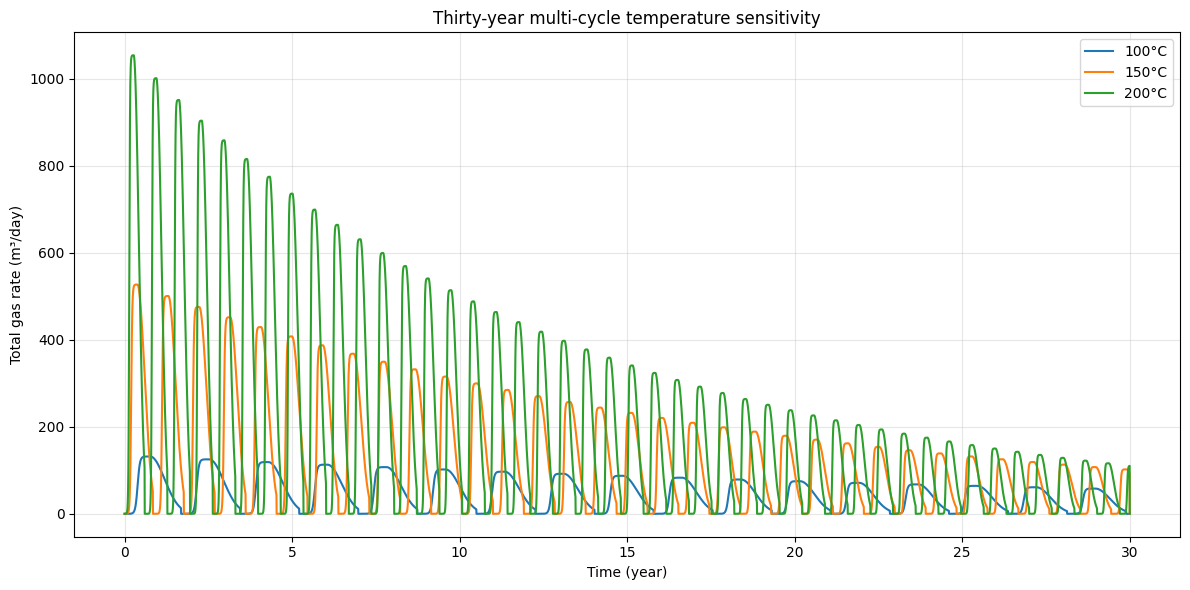

In [6]:

fig, ax = plt.subplots(figsize=(12, 6))
for T,h in multi.items(): ax.plot(h["time_year"],h["total_gas_rate_m3_day"],label=f"{T:.0f}°C")
ax.set(xlabel="Time (year)",ylabel="Total gas rate (m³/day)",title="Thirty-year multi-cycle temperature sensitivity")
ax.grid(alpha=0.3); ax.legend(); fig.tight_layout()
fig.savefig(OUTPUT_DIR / "02_30year_multicycle_rates.png",dpi=300,bbox_inches="tight")
plt.show()


## 4. Split total gas into 60% H₂ and 40% CO₂

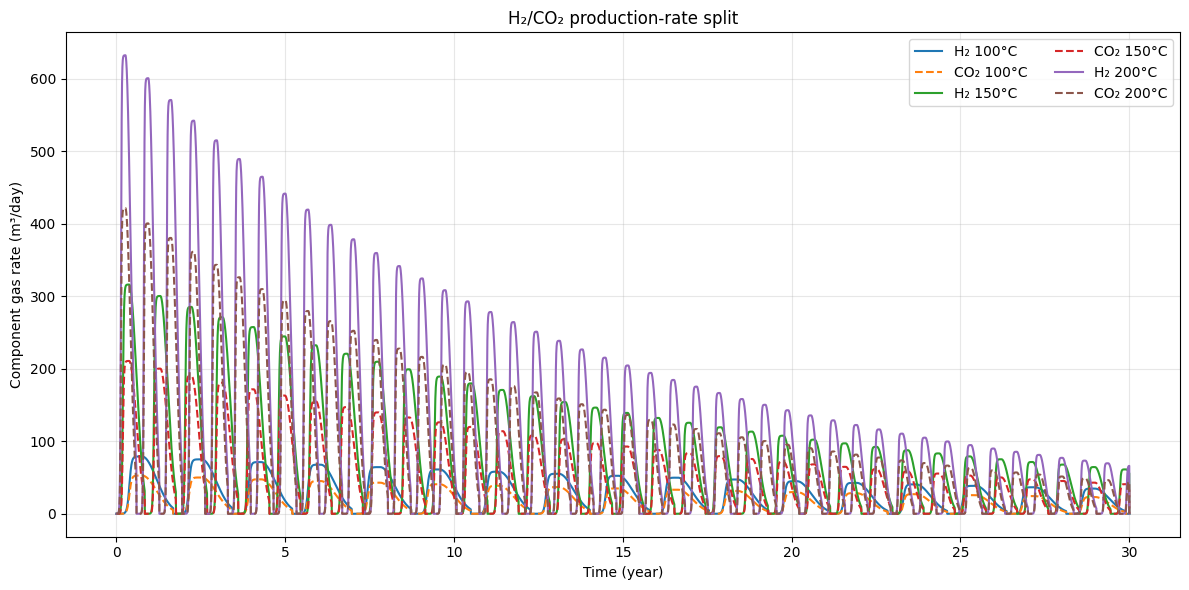

,temperature_C,cycles,30yr_H2_m3,30yr_CO2_m3
0,100.0,18,3.007127e+05,200475.140689
1,150.0,33,8.397297e+05,559819.782829
2,200.0,45,1.310728e+06,873818.996081


In [7]:

H2_FRACTION=0.60; CO2_FRACTION=0.40
fig, ax = plt.subplots(figsize=(12, 6))
summary=[]
for T,h in multi.items():
    h=h.copy(); h["H2_rate_m3_day"]=H2_FRACTION*h["total_gas_rate_m3_day"]; h["CO2_rate_m3_day"]=CO2_FRACTION*h["total_gas_rate_m3_day"]
    h["H2_cumulative_m3"]=H2_FRACTION*h["cumulative_total_gas_m3"]; h["CO2_cumulative_m3"]=CO2_FRACTION*h["cumulative_total_gas_m3"]
    multi[T]=h
    ax.plot(h["time_year"],h["H2_rate_m3_day"],label=f"H₂ {T:.0f}°C")
    ax.plot(h["time_year"],h["CO2_rate_m3_day"],linestyle="--",label=f"CO₂ {T:.0f}°C")
    summary.append({"temperature_C":T,"cycles":len(cycles[cycles.temperature_C==T]),"30yr_H2_m3":h.H2_cumulative_m3.iloc[-1],"30yr_CO2_m3":h.CO2_cumulative_m3.iloc[-1]})
ax.set(xlabel="Time (year)",ylabel="Component gas rate (m³/day)",title="H₂/CO₂ production-rate split")
ax.grid(alpha=0.3); ax.legend(ncol=2); fig.tight_layout()
fig.savefig(OUTPUT_DIR / "02_h2_co2_rate_split.png",dpi=300,bbox_inches="tight")
plt.show()
summary=pd.DataFrame(summary); summary


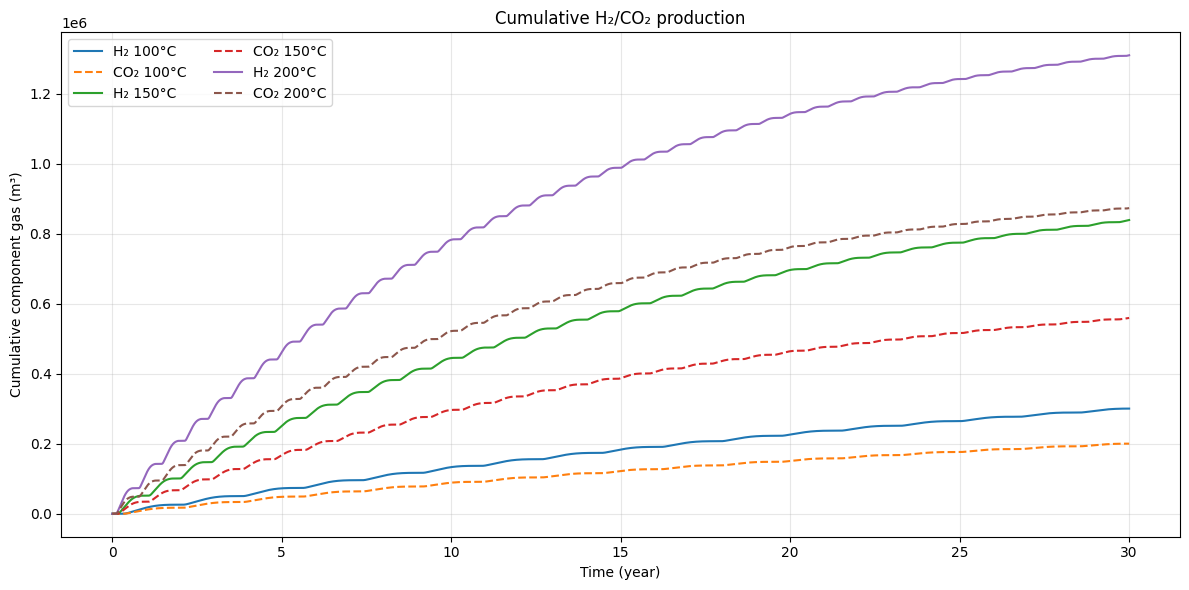

In [8]:

fig, ax = plt.subplots(figsize=(12, 6))
for T,h in multi.items():
    ax.plot(h["time_year"],h["H2_cumulative_m3"],label=f"H₂ {T:.0f}°C")
    ax.plot(h["time_year"],h["CO2_cumulative_m3"],linestyle="--",label=f"CO₂ {T:.0f}°C")
ax.set(xlabel="Time (year)",ylabel="Cumulative component gas (m³)",title="Cumulative H₂/CO₂ production")
ax.grid(alpha=0.3); ax.legend(ncol=2); fig.tight_layout()
fig.savefig(OUTPUT_DIR / "02_h2_co2_cumulative_split.png",dpi=300,bbox_inches="tight")
plt.show()
summary.to_csv(OUTPUT_DIR / "02_sensitivity_summary.csv",index=False)
cycles.to_csv(OUTPUT_DIR / "02_cycle_details.csv",index=False)



## Important interpretation

The multi-cycle section repeats the **analytical production trend** and applies a cycle-retention factor. It is a scheduling model, not a full THCM rerun during each refracture. Injection rate does not directly enter the current analytical generation equation; it affects transport in the coupled solver.
